<a href="https://www.kaggle.com/code/lalit7881/student-dropout-dataset?scriptVersionId=302116594" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/mohamedasak/online-learning-student-dropout-dataset/student_dropout_dataset.csv


## Import dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/mohamedasak/online-learning-student-dropout-dataset/student_dropout_dataset.csv")

In [3]:
df.head()

,student_id,age,region,enroll_date,exam_season,courses_enrolled,completed_assignments,completion_rate,login_frequency,last_activity_days_ago,forum_posts_count,dropout_score,label,label_multiclass,label_name
0,STU00001,26,Alexandria,2024-01-13,0,3,5,0.3571,5.29,10,5,0.1064,0,0,active
1,STU00002,23,Amman,2024-05-05,0,6,0,0.0000,0.84,7,0,0.6627,1,2,dropped
2,STU00003,17,Dubai,2024-03-12,0,3,1,0.0435,1.79,36,0,0.7299,1,2,dropped
3,STU00004,23,Alexandria,2024-12-12,0,6,13,0.4396,0.78,9,0,0.5315,1,1,at-risk
4,STU00005,20,Baghdad,2024-02-14,0,5,5,0.2078,0.92,11,0,0.7904,1,2,dropped


In [4]:
df.tail()

,student_id,age,region,enroll_date,exam_season,courses_enrolled,completed_assignments,completion_rate,login_frequency,last_activity_days_ago,forum_posts_count,dropout_score,label,label_multiclass,label_name
4995,STU04996,26,Baghdad,2024-07-10,0,2,7,0.6537,11.06,1,14,0.0000,0,0,active
4996,STU04997,34,Casablanca,2024-09-22,0,2,3,0.2559,5.16,15,3,0.3356,1,1,at-risk
4997,STU04998,18,Casablanca,2024-04-01,0,3,3,0.2242,5.05,5,6,0.2709,0,0,active
4998,STU04999,24,Beirut,2024-12-30,0,1,1,0.2659,4.04,1,4,0.2695,0,0,active
4999,STU05000,18,Beirut,2024-09-26,0,1,0,0.0741,3.43,1,3,0.2827,0,0,active


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   student_id              5000 non-null   object 
 1   age                     5000 non-null   int64  
 2   region                  5000 non-null   object 
 3   enroll_date             5000 non-null   object 
 4   exam_season             5000 non-null   int64  
 5   courses_enrolled        5000 non-null   int64  
 6   completed_assignments   5000 non-null   int64  
 7   completion_rate         5000 non-null   float64
 8   login_frequency         5000 non-null   float64
 9   last_activity_days_ago  5000 non-null   int64  
 10  forum_posts_count       5000 non-null   int64  
 11  dropout_score           5000 non-null   float64
 12  label                   5000 non-null   int64  
 13  label_multiclass        5000 non-null   int64  
 14  label_name              5000 non-null   

In [6]:
df.dtypes

student_id                 object
age                         int64
region                     object
enroll_date                object
exam_season                 int64
courses_enrolled            int64
completed_assignments       int64
completion_rate           float64
login_frequency           float64
last_activity_days_ago      int64
forum_posts_count           int64
dropout_score             float64
label                       int64
label_multiclass            int64
label_name                 object
dtype: object

In [7]:
df.shape

(5000, 15)

In [8]:
df.isnull().sum()

student_id                0
age                       0
region                    0
enroll_date               0
exam_season               0
courses_enrolled          0
completed_assignments     0
completion_rate           0
login_frequency           0
last_activity_days_ago    0
forum_posts_count         0
dropout_score             0
label                     0
label_multiclass          0
label_name                0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.nunique()

student_id                5000
age                         24
region                      10
enroll_date                365
exam_season                  2
courses_enrolled             7
completed_assignments       35
completion_rate           3048
login_frequency           1046
last_activity_days_ago      63
forum_posts_count           25
dropout_score             3648
label                        2
label_multiclass             3
label_name                   3
dtype: int64

In [11]:
df.columns

Index(['student_id', 'age', 'region', 'enroll_date', 'exam_season',
       'courses_enrolled', 'completed_assignments', 'completion_rate',
       'login_frequency', 'last_activity_days_ago', 'forum_posts_count',
       'dropout_score', 'label', 'label_multiclass', 'label_name'],
      dtype='object')

In [12]:
df.describe()

,age,exam_season,courses_enrolled,completed_assignments,completion_rate,login_frequency,last_activity_days_ago,forum_posts_count,dropout_score,label,label_multiclass
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.0000,5000.000000,5000.000000,5000.000000,5000.000000
mean,23.736600,0.094000,3.999400,5.188400,0.260985,3.453820,9.3564,4.212200,0.431556,0.659200,0.985800
std,4.583211,0.291858,1.997348,6.109466,0.249010,3.248316,9.4361,4.270131,0.263529,0.474026,0.816904
min,17.000000,0.000000,1.000000,0.000000,0.000000,0.100000,1.0000,0.000000,0.000000,0.000000,0.000000
25%,20.000000,0.000000,2.000000,1.000000,0.053900,0.980000,2.0000,1.000000,0.204575,0.000000,0.000000
50%,24.000000,0.000000,4.000000,3.000000,0.206700,2.440000,6.0000,3.000000,0.441550,1.000000,1.000000
75%,27.000000,0.000000,6.000000,7.000000,0.389025,4.942500,13.0000,6.000000,0.658325,1.000000,2.000000
max,40.000000,1.000000,7.000000,35.000000,1.000000,14.000000,70.0000,24.000000,1.000000,1.000000,2.000000


## EDA

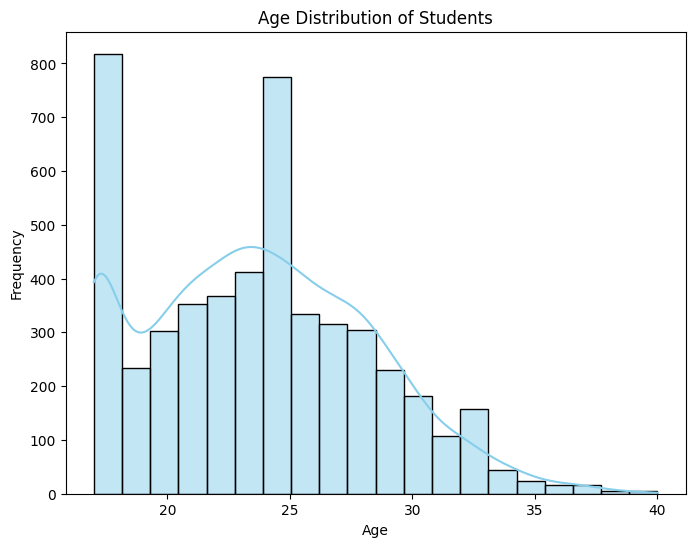

In [13]:
plt.figure(figsize=(8,6))

sns.histplot(
    df['age'],
    bins=20,
    kde=True,
    color='skyblue'
)

plt.title("Age Distribution of Students")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

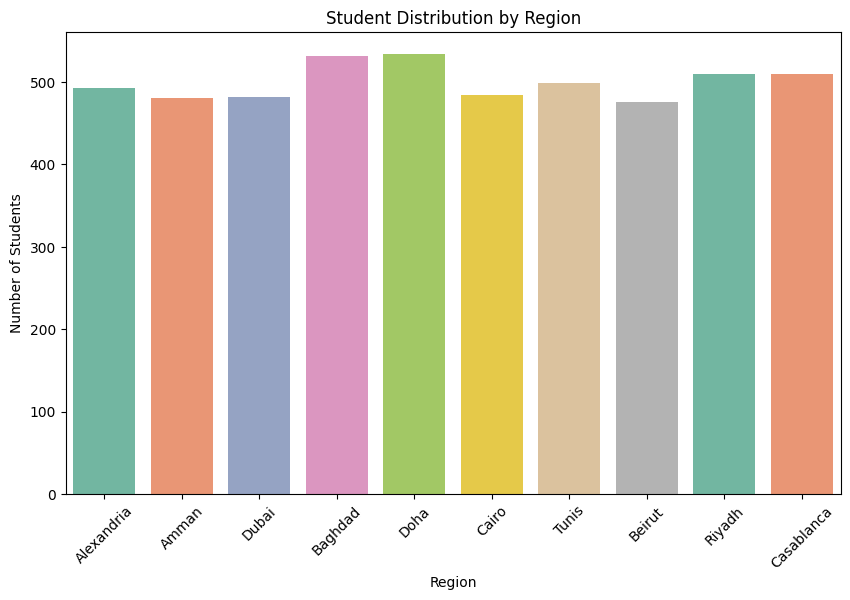

In [14]:
plt.figure(figsize=(10,6))

sns.countplot(
    x='region',
    data=df,
    palette='Set2'
)

plt.title("Student Distribution by Region")
plt.xlabel("Region")
plt.ylabel("Number of Students")
plt.xticks(rotation=45)

plt.show()

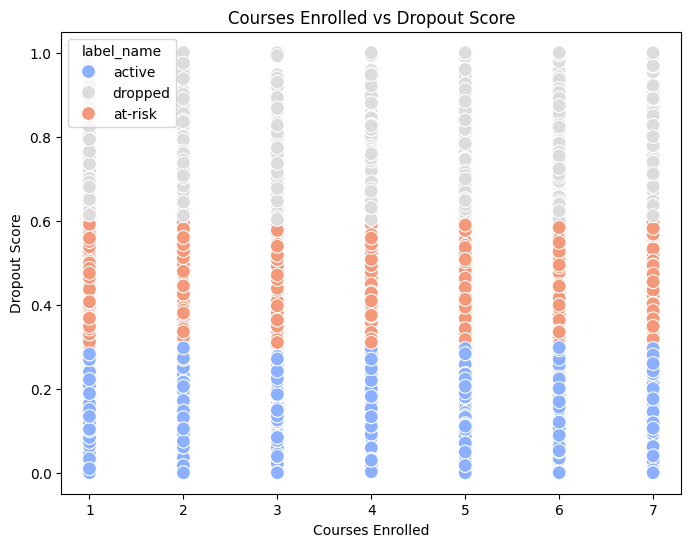

In [15]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='courses_enrolled',
    y='dropout_score',
    hue='label_name',
    data=df,
    palette='coolwarm',
    s=100
)

plt.title("Courses Enrolled vs Dropout Score")
plt.xlabel("Courses Enrolled")
plt.ylabel("Dropout Score")

plt.show()

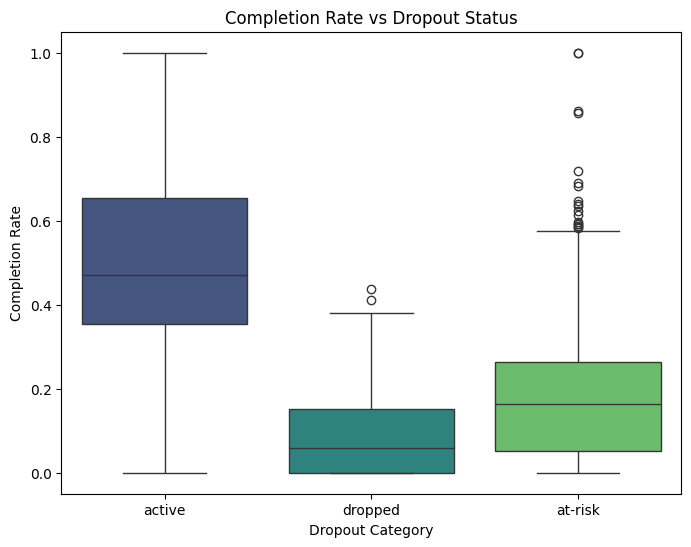

In [16]:
plt.figure(figsize=(8,6))

sns.boxplot(
    x='label_name',
    y='completion_rate',
    data=df,
    palette='viridis'
)

plt.title("Completion Rate vs Dropout Status")
plt.xlabel("Dropout Category")
plt.ylabel("Completion Rate")

plt.show()

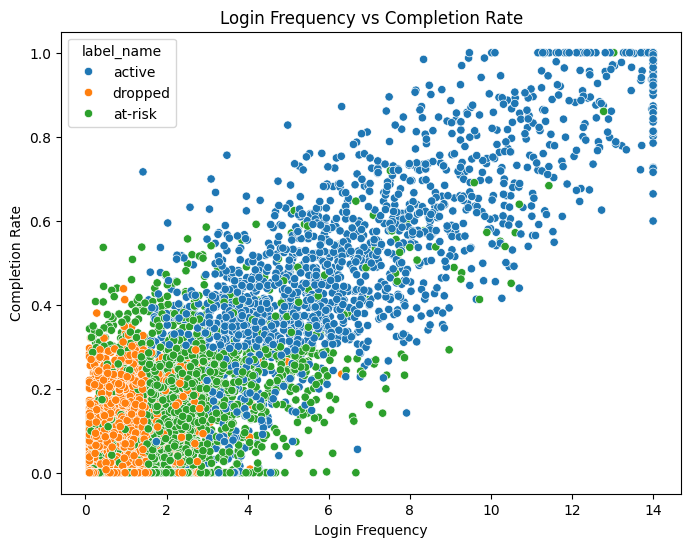

In [17]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='login_frequency',
    y='completion_rate',
    hue='label_name',
    palette='tab10',
    data=df
)

plt.title("Login Frequency vs Completion Rate")
plt.xlabel("Login Frequency")
plt.ylabel("Completion Rate")

plt.show()

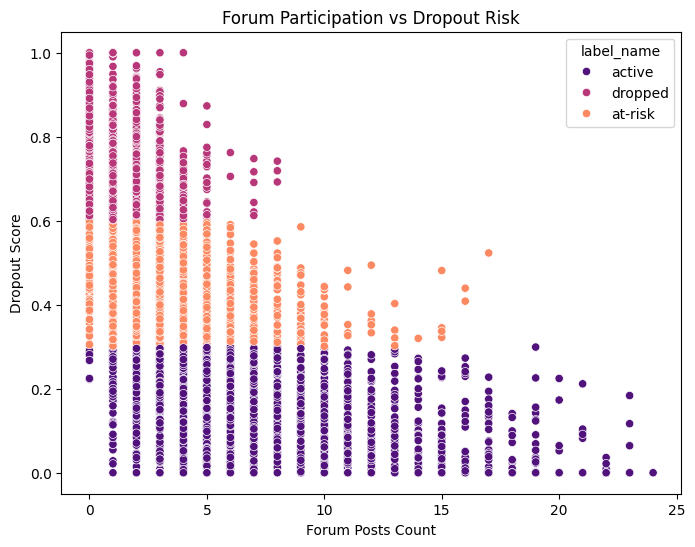

In [18]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='forum_posts_count',
    y='dropout_score',
    hue='label_name',
    palette='magma',
    data=df
)

plt.title("Forum Participation vs Dropout Risk")
plt.xlabel("Forum Posts Count")
plt.ylabel("Dropout Score")

plt.show()

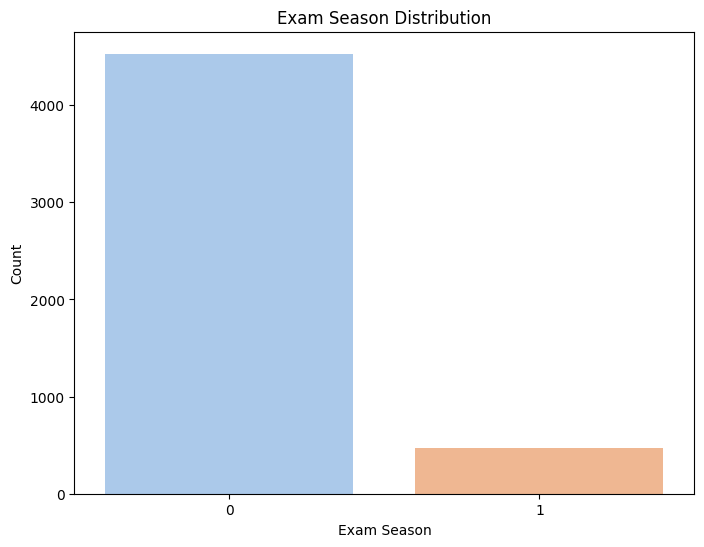

In [19]:
plt.figure(figsize=(8,6))

sns.countplot(
    x='exam_season',
    palette='pastel',
    data=df
)

plt.title("Exam Season Distribution")
plt.xlabel("Exam Season")
plt.ylabel("Count")

plt.show()

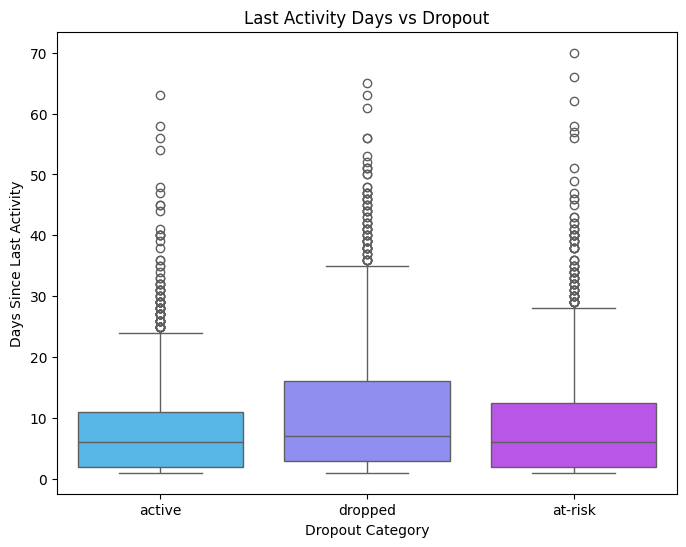

In [20]:
plt.figure(figsize=(8,6))

sns.boxplot(
    x='label_name',
    y='last_activity_days_ago',
    palette='cool',
    data=df
)

plt.title("Last Activity Days vs Dropout")
plt.xlabel("Dropout Category")
plt.ylabel("Days Since Last Activity")

plt.show()

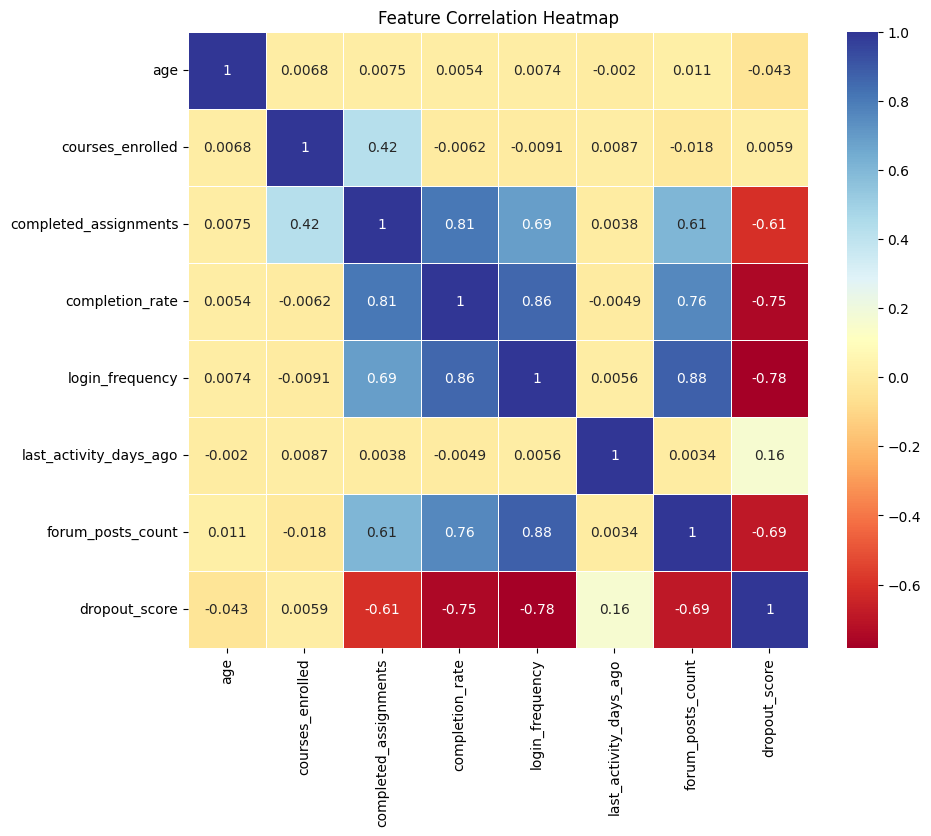

In [21]:
plt.figure(figsize=(10,8))

numeric_cols = [
    'age',
    'courses_enrolled',
    'completed_assignments',
    'completion_rate',
    'login_frequency',
    'last_activity_days_ago',
    'forum_posts_count',
    'dropout_score'
]

sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    cmap='RdYlBu',
    linewidths=0.5
)

plt.title("Feature Correlation Heatmap")

plt.show()

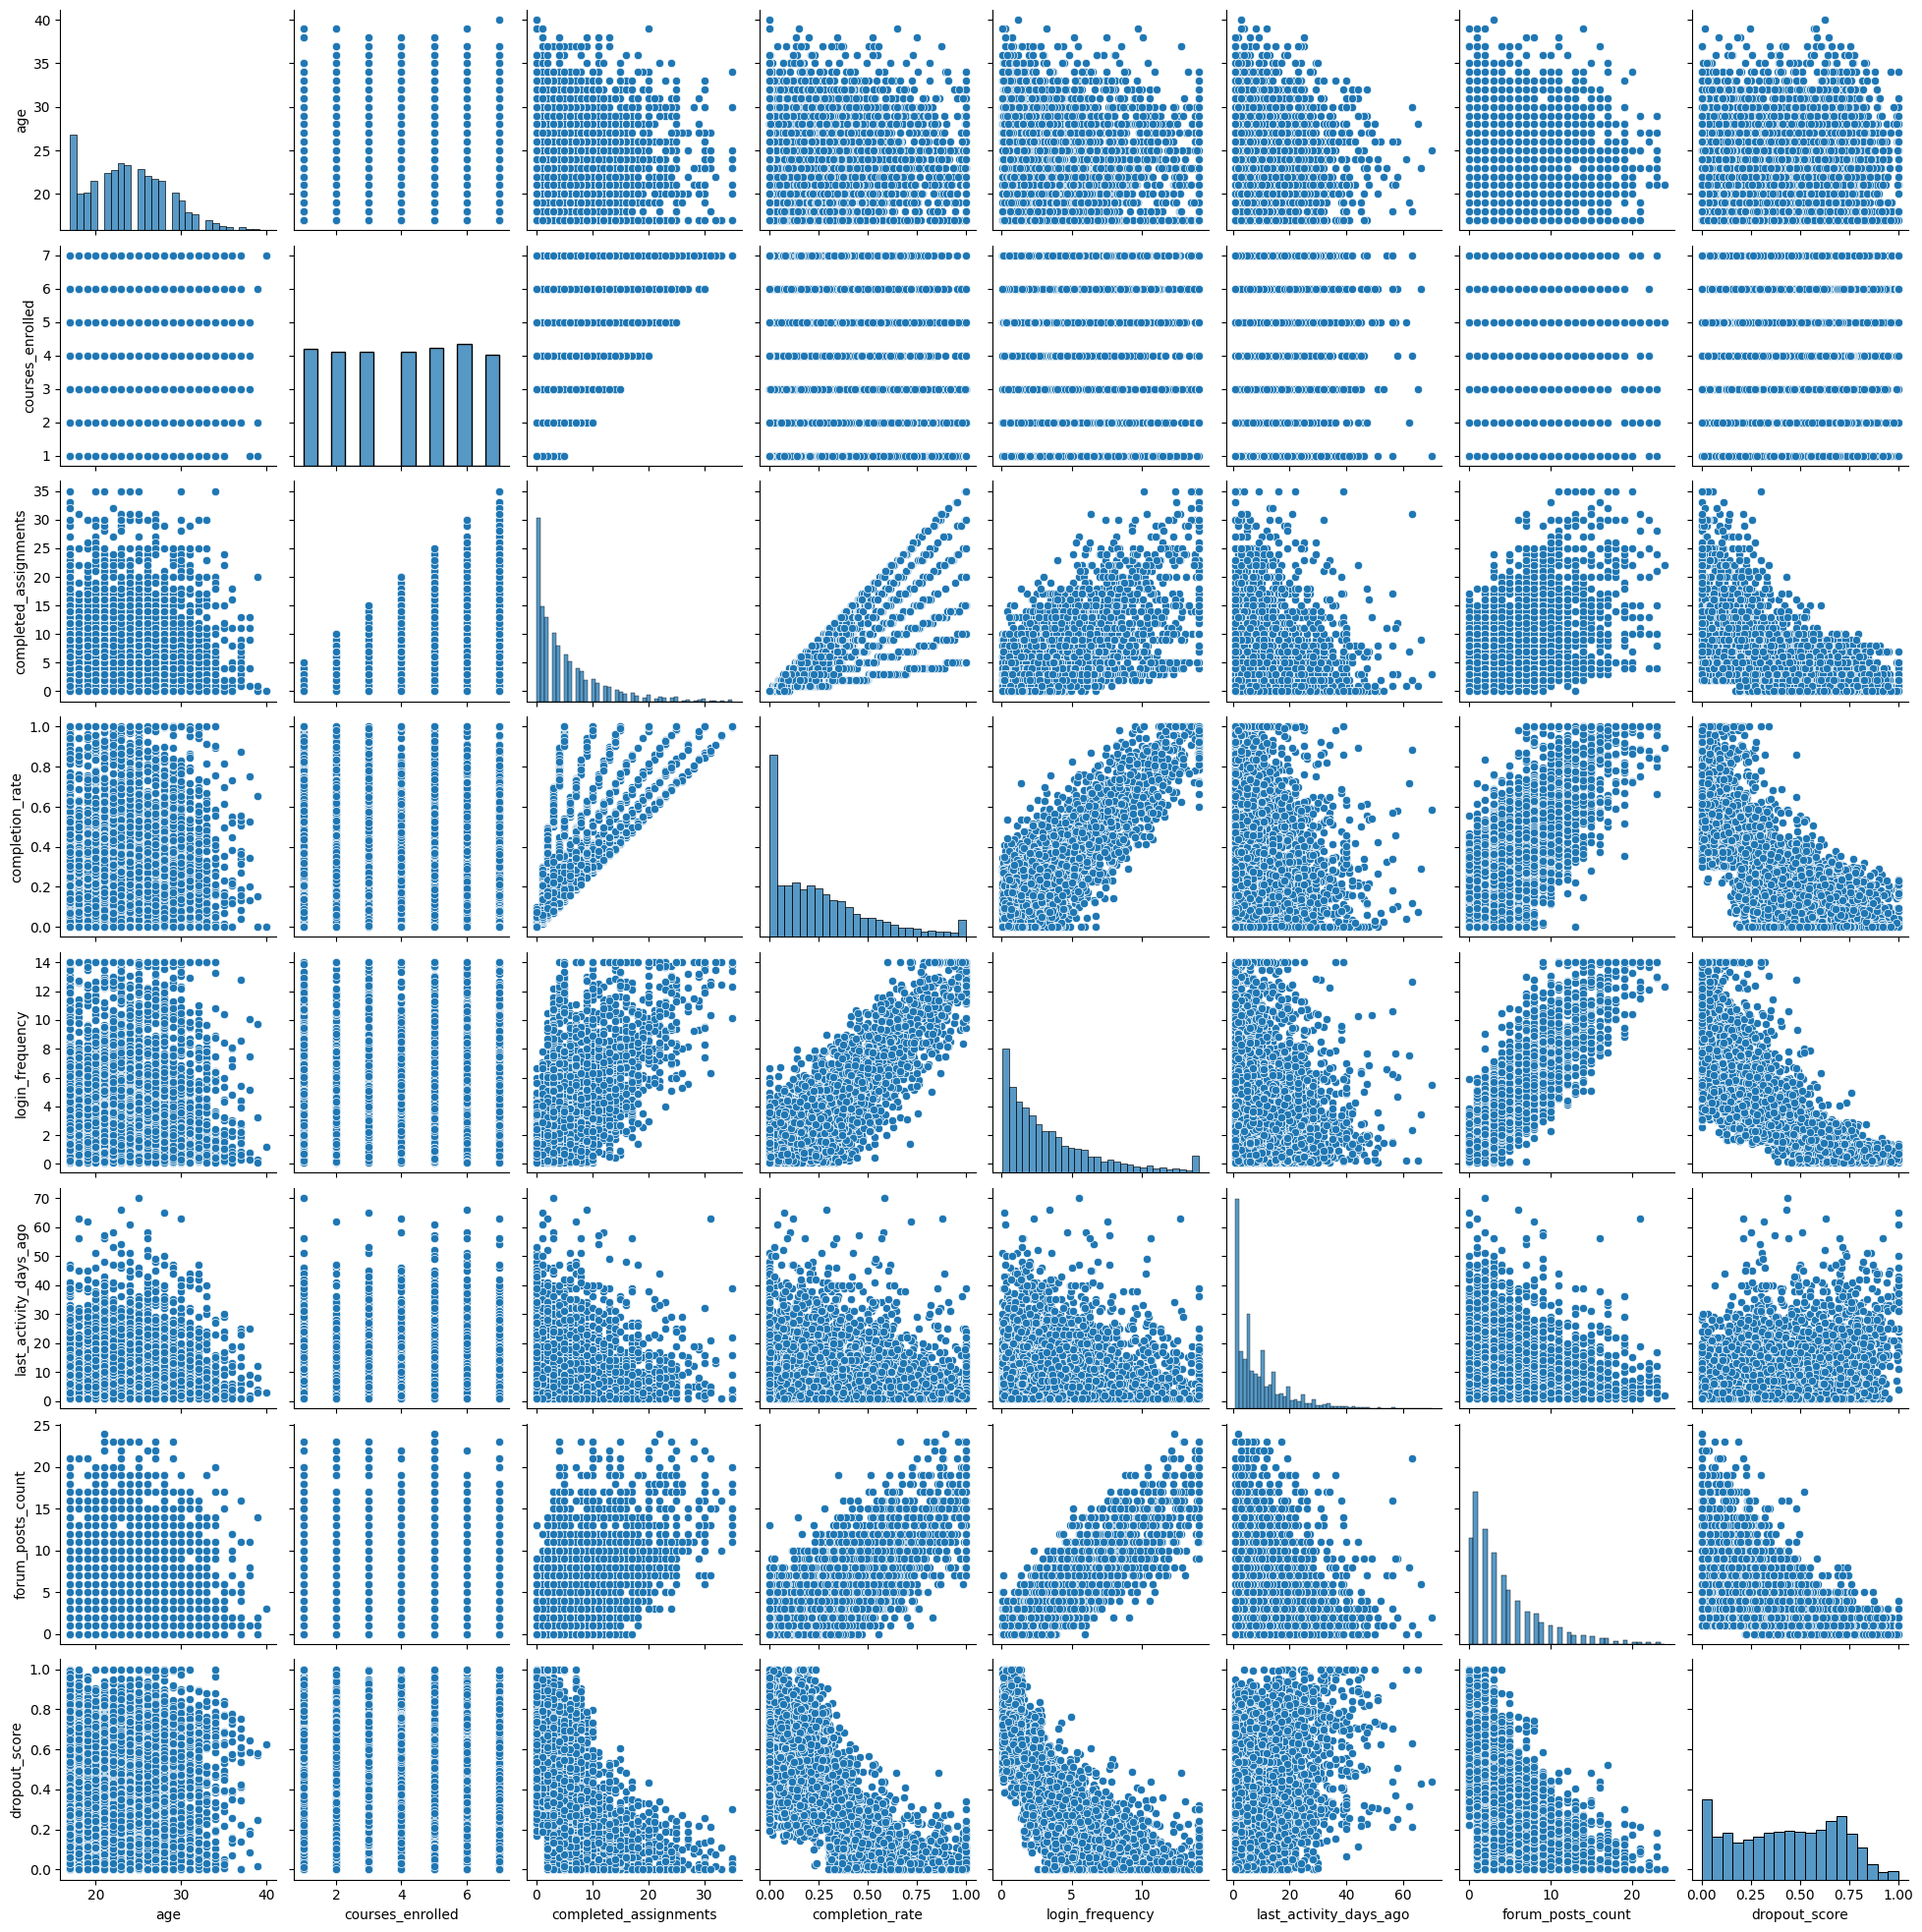

In [22]:
sns.pairplot(
    df[numeric_cols],
    palette='husl'
)

plt.show()

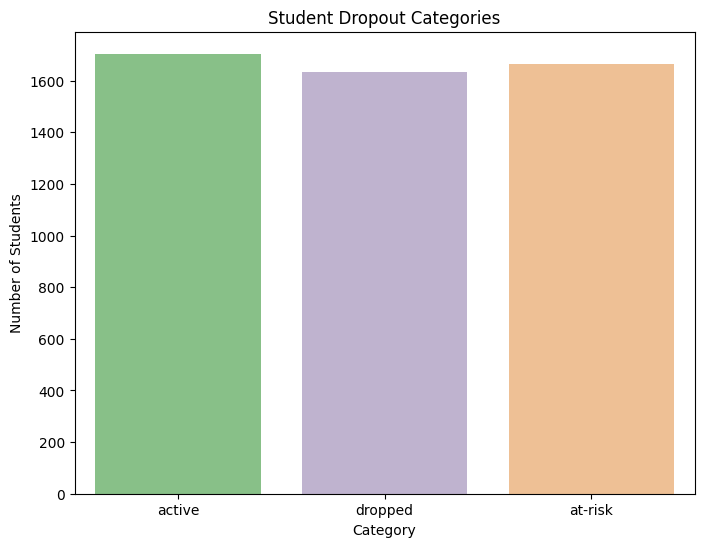

In [23]:
plt.figure(figsize=(8,6))

sns.countplot(
    x='label_name',
    palette='Accent',
    data=df
)

plt.title("Student Dropout Categories")
plt.xlabel("Category")
plt.ylabel("Number of Students")

plt.show()

## Feature engineering

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import label_binarize

from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

In [25]:
df['enroll_date'] = pd.to_datetime(df['enroll_date'])

df['enroll_year'] = df['enroll_date'].dt.year
df['enroll_month'] = df['enroll_date'].dt.month
df['enroll_day'] = df['enroll_date'].dt.day

df.drop('enroll_date', axis=1, inplace=True)

In [26]:
df = df.drop(['student_id','label','label_name'], axis=1)

In [27]:
le = LabelEncoder()

categorical_cols = ['region','exam_season']

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [28]:
X = df.drop('label_multiclass', axis=1)

y = df['label_multiclass']

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [30]:
models = {

    "Logistic Regression": LogisticRegression(max_iter=1000),

    "Decision Tree": DecisionTreeClassifier(),

    "Random Forest": RandomForestClassifier(),

    "Support Vector Machine": SVC(probability=True),

    "KNN": KNeighborsClassifier(),

    "Naive Bayes": GaussianNB()

}

In [31]:
for name, model in models.items():

    print("\n"+"="*60)
    print("MODEL :", name)
    print("="*60)

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)*100

    print("Accuracy :", round(accuracy,2), "%")


MODEL : Logistic Regression
Accuracy : 80.2 %

MODEL : Decision Tree
Accuracy : 100.0 %

MODEL : Random Forest
Accuracy : 100.0 %

MODEL : Support Vector Machine
Accuracy : 33.3 %

MODEL : KNN
Accuracy : 67.2 %

MODEL : Naive Bayes
Accuracy : 88.9 %


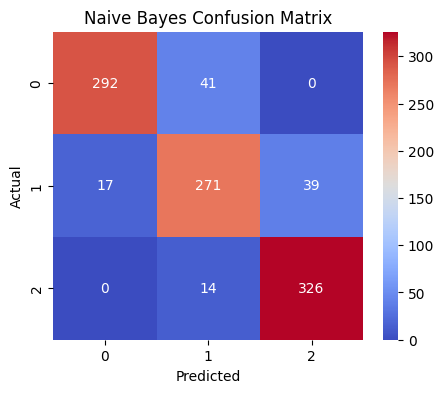

In [32]:
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5,4))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='coolwarm'
    )

    plt.title(name + " Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

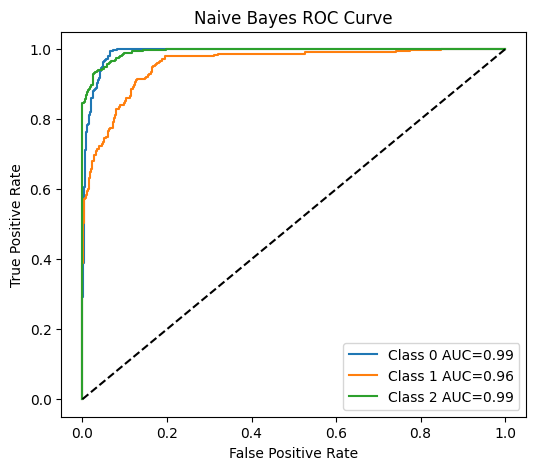

In [33]:
    y_prob = model.predict_proba(X_test)

    y_test_bin = label_binarize(y_test, classes=np.unique(y))

    n_classes = y_test_bin.shape[1]

    plt.figure(figsize=(6,5))

    for i in range(n_classes):

        fpr, tpr, _ = roc_curve(y_test_bin[:,i], y_prob[:,i])

        roc_auc = auc(fpr, tpr)

        plt.plot(
            fpr,
            tpr,
            label=f"Class {i} AUC={roc_auc:.2f}"
        )

    plt.plot([0,1],[0,1],'k--')

    plt.title(name + " ROC Curve")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()

    plt.show()

## Thank you...pls upvote!!!!!!!